# 1D Gradient-Damage Bar on an Elastic Foundation — QS vs Dynamic

Same problem, two solvers:

1. **Quasi-static**: alternate minimization at each load level.
2. **Dynamic**: Newmark-$\beta$ with alternate minimization at each time step.

Idea: introduce a small parameter $\eta$ (wave time / loading time). As $\eta \to 0$ inertia drops out and the dynamic solution should match the QS one. We check that here.

Model is the dimensionless thermoelastic gradient-damage one, **no thermal coupling** — just an elastically supported bar with AT1 gradient damage.


## Model in short

State variables on $\hat x \in [0,1]$: displacement $\hat u(\hat x, t)$ and damage $\alpha(\hat x, t) \in [0,1]$.

### Time scales

Two of them:
- fast (wave) time $\tau$, scale $L/c_0$,
- slow (loading) time $t$, scale $t_0^\text{load}$.

Their ratio is
$$\eta = \frac{L/c_0}{t_0^\text{load}}, \qquad \tau = \frac{t}{\eta}.$$

Working in slow time, the chain rule gives $\partial_\tau = \eta^{-1}\partial_t$, so the kinetic energy picks up a factor $\eta^2$. The loading interval is normalized to $t \in [0,1]$.

### Dimensionless energies

Foundation parameter $\Lambda^2 = kL^2/E_0$, relative damage length $\hat\ell = \ell/L$:
$$
\hat P(\hat u, \alpha) = \tfrac{1}{2}\!\int_0^1\!\left[(1-\alpha)^2 (\hat u')^2 + \Lambda^2 \hat u^2\right]\,d\hat x
$$
$$
\hat S(\alpha) = \int_0^1\!\left[\alpha + \hat\ell^2 (\alpha')^2\right]\,d\hat x \quad\text{(AT1)}
$$
$$
\hat K(\dot{\hat u}) = \tfrac{\eta^2}{2}\!\int_0^1 \dot{\hat u}^2\,d\hat x
$$

### Governing equations

**QS** ($\eta = 0$): minimize $\hat P + \hat S$ over $(\hat u, \alpha)$, with $\dot\alpha \ge 0$.

**Dynamic** ($\eta > 0$):
$$
\eta^2 \ddot{\hat u} = \big((1-\alpha)^2 \hat u'\big)' - \Lambda^2 \hat u,
$$
plus the same gradient-damage VI for $\alpha$.

### BCs

- $\hat u(0,t) = 0$ (clamped left),
- $\hat u(1,t) = \hat U(t)$ (pulled right; for dynamic, also $\dot{\hat U}, \ddot{\hat U}$),
- $\alpha = 0$ at both ends, so the damage localizes in the interior.

### Loading

Smooth ramp $\hat U(t) = \dot U_p(\sqrt{T_0^2 + t^2} - T_0)$ on $t \in [0,1]$, with $\dot U_p$ chosen so $\hat U(1) = \hat U_\text{max}$.

Note: we don't need a separate "total time" — the slow time is normalized to 1 by the choice of $\eta$.


## Imports

In [ ]:
import os

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import dolfinx
from dolfinx import mesh as df_mesh, fem
import dolfinx.fem.petsc
import ufl

from mpi4py import MPI
from petsc4py import PETSc

comm = MPI.COMM_WORLD


## `SNESProblem` helper

Same wrapper used in the original notebooks. Just packages a UFL residual + unknown into the callbacks `PETSc.SNES` wants.


In [605]:
class SNESProblem:
    def __init__(self, F, u, bcs, J=None):
        V = u.function_space
        du = ufl.TrialFunction(V)
        self.L = fem.form(F)
        if J is None:
            self.a = fem.form(ufl.derivative(F, u, du))
        else:
            self.a = fem.form(J)
        self.bcs = bcs
        self.u = u

    def F(self, snes, x, F):
        x.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)
        x.copy(self.u.x.petsc_vec)
        self.u.x.petsc_vec.ghostUpdate(
            addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD
        )
        with F.localForm() as f_local:
            f_local.set(0.0)
        fem.petsc.assemble_vector(F, self.L)
        fem.petsc.apply_lifting(F, [self.a], bcs=[self.bcs], x0=[x], alpha=-1.0)
        F.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
        fem.petsc.set_bc(F, self.bcs, x, -1.0)

    def J(self, snes, x, J, P):
        J.zeroEntries()
        fem.petsc.assemble_matrix(J, self.a, bcs=self.bcs)
        J.assemble()


## Parameters

Three independent dimensionless model parameters: $\hat\ell$, $\Lambda$, $\eta$.

Both solvers are step-count based:
- `N_steps_qs` = number of QS load steps.
- `N_steps_dyn` = number of dynamic time steps. The dynamic time step is computed internally as $\Delta t = 1/N_\text{steps,dyn}$ (slow-time interval is normalized to 1).

If you ask for $N$ steps you get exactly $N$ recorded states — no off-by-one.


In [ ]:
model_parameters = {
    "l_hat":  0.02,   # relative damage length l/L
    "Lambda": 1.0,    # foundation parameter sqrt(k L^2 / E0)
    "eta":    1e-2,   # wave / loading time. small -> QS-like
}

mesh_parameters = {"nx": 200}

loading_parameters = {
    "U_max":        1.4,   # peak imposed displacement
    "T0":           1.0,   # smoothing window at t=0
    "N_steps_qs":   20,    # number of QS load steps
    "N_steps_dyn":  60,    # number of dynamic time steps
}

AltMin_parameters  = {"max_iter": 200, "tol": 1e-7}
Newmark_parameters = {"beta": 0.25, "gamma": 0.5}

if comm.rank == 0:
    for d in (model_parameters, mesh_parameters, loading_parameters,
              AltMin_parameters, Newmark_parameters):
        print(d)


{'l_hat': 0.02, 'Lambda': 1.0, 'eta': 0.01}
{'nx': 200}
{'U_max': 1.4, 'T0': 1.0, 'N_steps_qs': 20, 'N_steps_dyn': 60}
{'max_iter': 200, 'tol': 1e-07}
{'beta': 0.25, 'gamma': 0.5}


## Mesh, spaces, surface tags

Uniform 1D mesh, $P_1$ Lagrange for both $\hat u$ and $\alpha$. The two endpoint facets get tags so the reaction force at $\hat x = 1$ can be written as a surface integral.


In [607]:
domain = df_mesh.create_interval(comm, mesh_parameters["nx"], (0.0, 1.0))
gdim = domain.topology.dim    # 1
fdim = gdim - 1               # 0 (endpoints)

V_u     = fem.functionspace(domain, ("Lagrange", 1))
V_alpha = fem.functionspace(domain, ("Lagrange", 1))

# state at "current" time n
u     = fem.Function(V_u, name="Displacement")
v     = fem.Function(V_u, name="Velocity")
a     = fem.Function(V_u, name="Acceleration")
# state at "new" time n+1
u_new = fem.Function(V_u)
v_new = fem.Function(V_u)
a_new = fem.Function(V_u)

# damage + bounds for the VI
alpha          = fem.Function(V_alpha, name="Damage")
alpha_old_iter = fem.Function(V_alpha)
alpha_lb       = fem.Function(V_alpha)
alpha_ub       = fem.Function(V_alpha)

state = {"u": u, "v": v, "a": a, "alpha": alpha}

# mark left (x=0) and right (x=1) endpoints
def left_marker(x):  return np.isclose(x[0], 0.0)
def right_marker(x): return np.isclose(x[0], 1.0)

left_facets  = df_mesh.locate_entities_boundary(domain, fdim, left_marker)
right_facets = df_mesh.locate_entities_boundary(domain, fdim, right_marker)

# tag left = 1, right = 2 so we can write ds(2) for "right end"
all_facets = np.concatenate([left_facets, right_facets]).astype(np.int32)
markers    = np.concatenate([
    np.full(len(left_facets),  1, dtype=np.int32),
    np.full(len(right_facets), 2, dtype=np.int32),
])
sort_ix = np.argsort(all_facets)
mt = df_mesh.meshtags(domain, fdim, all_facets[sort_ix], markers[sort_ix])

dx = ufl.Measure("dx", domain=domain)
ds = ufl.Measure("ds", domain=domain, subdomain_data=mt)


## Boundary conditions

Left end always zero. Right end: $\hat u(1,t) = \hat U(t)$. For dynamic we also need $\dot{\hat U}$ and $\ddot{\hat U}$ at the right (Newmark consistency). Damage Dirichlet $\alpha=0$ on both ends so the band can only form inside.

All boundary values are kept as `fem.Constant`, so updating them each step doesn't re-build any forms.


In [608]:
# constants holding BC values (updated each step)
u_left_val  = fem.Constant(domain, PETSc.ScalarType(0.0))
u_right_val = fem.Constant(domain, PETSc.ScalarType(0.0))
v_left_val  = fem.Constant(domain, PETSc.ScalarType(0.0))
v_right_val = fem.Constant(domain, PETSc.ScalarType(0.0))
a_left_val  = fem.Constant(domain, PETSc.ScalarType(0.0))
a_right_val = fem.Constant(domain, PETSc.ScalarType(0.0))

# boundary dofs
left_dofs_u      = fem.locate_dofs_topological(V_u,     fdim, left_facets)
right_dofs_u     = fem.locate_dofs_topological(V_u,     fdim, right_facets)
left_dofs_alpha  = fem.locate_dofs_topological(V_alpha, fdim, left_facets)
right_dofs_alpha = fem.locate_dofs_topological(V_alpha, fdim, right_facets)

# u, v, a Dirichlet BCs
bc_u_left  = fem.dirichletbc(u_left_val,  left_dofs_u,  V_u)
bc_u_right = fem.dirichletbc(u_right_val, right_dofs_u, V_u)
bc_v_left  = fem.dirichletbc(v_left_val,  left_dofs_u,  V_u)
bc_v_right = fem.dirichletbc(v_right_val, right_dofs_u, V_u)
bc_a_left  = fem.dirichletbc(a_left_val,  left_dofs_u,  V_u)
bc_a_right = fem.dirichletbc(a_right_val, right_dofs_u, V_u)

# alpha = 0 at both ends, fixed
bc_alpha_left  = fem.dirichletbc(PETSc.ScalarType(0.0), left_dofs_alpha,  V_alpha)
bc_alpha_right = fem.dirichletbc(PETSc.ScalarType(0.0), right_dofs_alpha, V_alpha)

bcs_u     = [bc_u_left,     bc_u_right]
bcs_v     = [bc_v_left,     bc_v_right]
bcs_a     = [bc_a_left,     bc_a_right]
bcs_alpha = [bc_alpha_left, bc_alpha_right]


## Energies and residuals

Define $\hat P$, $\hat S$, $\hat K$ once, reuse them in both solvers.

The reaction force at the right end is the stress at $\hat x = 1$, written as $\int (1-\alpha)^2 \hat u' \,ds$ on facet tag 2 (in 1D it just picks up the point value).


In [609]:
# wrap parameters as fem.Constant so they can live in UFL forms
Lambda_c  = fem.Constant(domain, PETSc.ScalarType(model_parameters["Lambda"]))
l_hat_c   = fem.Constant(domain, PETSc.ScalarType(model_parameters["l_hat"]))
eta_c     = fem.Constant(domain, PETSc.ScalarType(model_parameters["eta"]))
# dynamic dt is 1 / N_steps_dyn (slow-time interval = 1)
delta_t_c = fem.Constant(domain, PETSc.ScalarType(1.0 / loading_parameters["N_steps_dyn"]))

# strain and stress in 1D
def strain(w):         return w.dx(0)
def stress(w, alpha_): return (1.0 - alpha_)**2 * strain(w)

# energy densities (non-dim)
strain_e_density     = 0.5 * (1.0 - alpha)**2 * strain(u)**2
foundation_e_density = 0.5 * Lambda_c**2 * u**2
fracture_e_density   = alpha + l_hat_c**2 * alpha.dx(0)**2   # AT1
kinetic_e_density    = 0.5 * eta_c**2 * v**2

# integrated energies
strain_energy     = strain_e_density     * dx
foundation_energy = foundation_e_density * dx
potential_energy  = strain_energy + foundation_energy
fracture_energy   = fracture_e_density   * dx
kinetic_energy    = kinetic_e_density    * dx

# scalar forms for post-processing
strain_energy_form     = fem.form(strain_energy)
foundation_energy_form = fem.form(foundation_energy)
fracture_energy_form   = fem.form(fracture_energy)
kinetic_energy_form    = fem.form(kinetic_energy)
reaction_right_form    = fem.form(stress(u, alpha) * ds(2))
error_L2_alpha_form    = fem.form((alpha - alpha_old_iter)**2 * dx)

# test functions
u_test     = ufl.TestFunction(V_u)
alpha_test = ufl.TestFunction(V_alpha)

# QS residuals: dPi/du and dPi/dalpha with Pi = P + S
Res_u_qs     = ufl.derivative(potential_energy, u, u_test)
Res_alpha_qs = ufl.derivative(potential_energy + fracture_energy, alpha, alpha_test)

# dynamic acceleration residual (in slow time): eta^2 * a_new * test + dP/du
# u will be replaced by its Newmark expression below
Res_acc = eta_c**2 * a_new * u_test * dx + ufl.derivative(potential_energy, u, u_test)


## Loading

Smooth ramp built with `sympy` so we can differentiate symbolically and get $\dot U$, $\ddot U$ for free. $\dot U_p$ is tuned so $U(1) = U_\text{max}$.


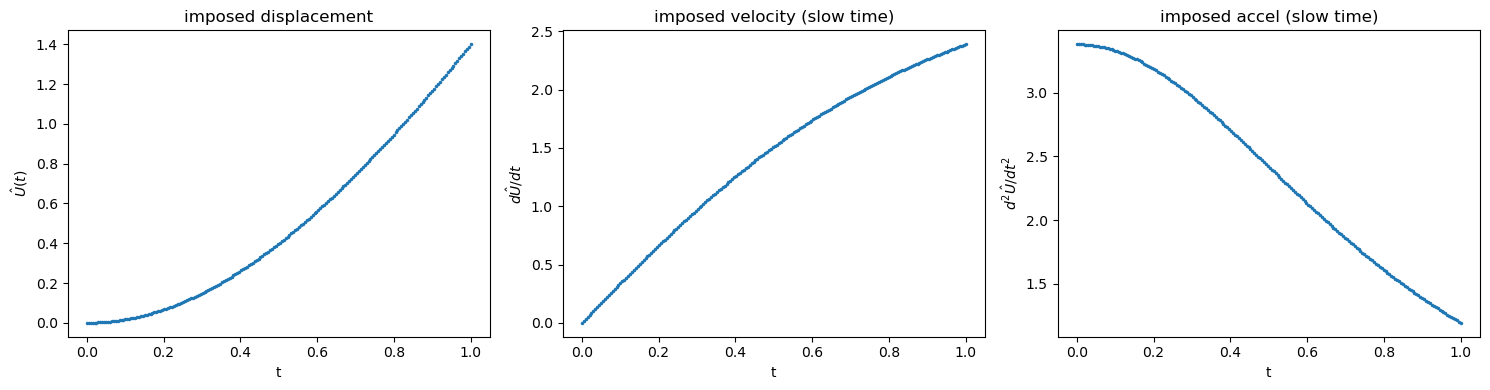

In [610]:
t_sp   = sp.Symbol("t", real=True)
T0_v   = loading_parameters["T0"]
Umax_v = loading_parameters["U_max"]

# loading interval is [0, 1] in slow time, so pick Udot_p s.t. U(1) = Umax
Udot_p = Umax_v / (np.sqrt(T0_v**2 + 1.0**2) - T0_v)

U_imp_sp = Udot_p * (sp.sqrt(T0_v**2 + t_sp**2) - T0_v)
V_imp_sp = sp.diff(U_imp_sp, t_sp)
A_imp_sp = sp.diff(V_imp_sp, t_sp)

# lambdify for cheap calls inside loops
U_fn = sp.lambdify(t_sp, U_imp_sp, "numpy")
V_fn = sp.lambdify(t_sp, V_imp_sp, "numpy")
A_fn = sp.lambdify(t_sp, A_imp_sp, "numpy")

# sanity plot of U, dU/dt, d2U/dt2
if comm.rank == 0:
    t_grid = np.linspace(0.0, 1.0, 200)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(t_grid, U_fn(t_grid), marker=".", linestyle="none", markersize=3)
    axes[0].set_xlabel("t"); axes[0].set_ylabel(r"$\hat{U}(t)$")
    axes[0].set_title("imposed displacement")
    axes[1].plot(t_grid, V_fn(t_grid), marker=".", linestyle="none", markersize=3)
    axes[1].set_xlabel("t"); axes[1].set_ylabel(r"$d\hat{U}/dt$")
    axes[1].set_title("imposed velocity (slow time)")
    axes[2].plot(t_grid, A_fn(t_grid), marker=".", linestyle="none", markersize=3)
    axes[2].set_xlabel("t"); axes[2].set_ylabel(r"$d^2\hat{U}/dt^2$")
    axes[2].set_title("imposed accel (slow time)")
    plt.tight_layout(); plt.show()


## QS solver

At each load level, alternate:
1. solve linear elasticity for $\hat u$ at fixed $\alpha$ (`ksponly` + LU),
2. solve bound-constrained damage for $\alpha$ at fixed $\hat u$ (`vinewtonrsls`),

until $\|\alpha^{(k+1)}-\alpha^{(k)}\|_{L^2} < \text{tol}$. Then push the irreversibility lower bound: $\alpha_\text{lb} \leftarrow \alpha$.


In [611]:
# Jacobians (linearization of the residuals)
J_u_qs     = ufl.derivative(Res_u_qs,     u,     ufl.TrialFunction(V_u))
J_alpha_qs = ufl.derivative(Res_alpha_qs, alpha, ufl.TrialFunction(V_alpha))

elastic_problem_qs = SNESProblem(Res_u_qs,     u,     bcs_u,     J=J_u_qs)
damage_problem_qs  = SNESProblem(Res_alpha_qs, alpha, bcs_alpha, J=J_alpha_qs)

# PETSc work vectors / matrices
b_u_qs       = fem.petsc.create_vector(V_u)
J_u_qs_m     = fem.petsc.create_matrix(elastic_problem_qs.a)
b_alpha_qs   = fem.petsc.create_vector(V_alpha)
J_alpha_qs_m = fem.petsc.create_matrix(damage_problem_qs.a)

# elastic solver (linear problem)
solver_u_qs = PETSc.SNES().create()
solver_u_qs.setType("ksponly")
solver_u_qs.setFunction(elastic_problem_qs.F, b_u_qs)
solver_u_qs.setJacobian(elastic_problem_qs.J, J_u_qs_m)
solver_u_qs.setTolerances(rtol=1.0e-9, max_it=50)
solver_u_qs.getKSP().setType("preonly")
solver_u_qs.getKSP().getPC().setType("lu")
solver_u_qs.getKSP().getPC().setFactorSolverType("mumps")

# damage solver (variational inequality)
solver_alpha_qs = PETSc.SNES().create()
solver_alpha_qs.setType("vinewtonrsls")
solver_alpha_qs.setFunction(damage_problem_qs.F, b_alpha_qs)
solver_alpha_qs.setJacobian(damage_problem_qs.J, J_alpha_qs_m)
solver_alpha_qs.setTolerances(rtol=1.0e-9, max_it=50)
solver_alpha_qs.getKSP().setType("preonly")
solver_alpha_qs.getKSP().getPC().setType("lu")
solver_alpha_qs.setVariableBounds(alpha_lb.x.petsc_vec, alpha_ub.x.petsc_vec)
solver_alpha_qs.getKSP().getPC().setFactorSolverType("mumps")


### QS load loop

Sample the smooth ramp at exactly $N$ slow-time points $t_i = i/N$ for $i = 1, \dots, N$. So the recorded arrays have length $N = $ `N_steps_qs`. The $t=0$ state (zero everything) is not recorded.


In [612]:
# zero everything before starting
u.x.array[:] = 0.0
v.x.array[:] = 0.0
a.x.array[:] = 0.0
alpha.x.array[:]    = 0.0
alpha_lb.x.array[:] = 0.0
alpha_ub.x.array[:] = 1.0

qs = {"t": [], "U": [], "F": [],
      "P_el": [], "P_f": [], "S": [], "total": []}

N_qs      = loading_parameters["N_steps_qs"]
# N points from t=1/N to t=1 (inclusive). No t=0 entry.
t_grid_qs = np.linspace(0.0, 1.0, N_qs + 1)[1:]

for i, ti in enumerate(t_grid_qs):
    # update right-end displacement BC
    u_right_val.value = float(U_fn(ti))

    # alt min: u <-> alpha until alpha stops changing
    n_alt = 0
    for n_alt in range(1, AltMin_parameters["max_iter"] + 1):
        solver_u_qs.solve(None, u.x.petsc_vec)
        u.x.petsc_vec.ghostUpdate(
            addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD
        )
        solver_alpha_qs.solve(None, alpha.x.petsc_vec)
        alpha.x.petsc_vec.ghostUpdate(
            addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD
        )

        err = comm.allreduce(fem.assemble_scalar(error_L2_alpha_form), op=MPI.SUM)
        err_alpha = float(np.sqrt(max(err, 0.0)))
        alpha_old_iter.x.array[:] = alpha.x.array

        if err_alpha <= AltMin_parameters["tol"]:
            break

    # irreversibility: lower bound = current alpha for the next step
    alpha_lb.x.array[:] = alpha.x.array

    # record
    qs["t"].append(float(ti))
    qs["U"].append(float(u_right_val.value))
    qs["F"].append(comm.allreduce(fem.assemble_scalar(reaction_right_form),    op=MPI.SUM))
    qs["P_el"].append(comm.allreduce(fem.assemble_scalar(strain_energy_form),     op=MPI.SUM))
    qs["P_f"].append(comm.allreduce(fem.assemble_scalar(foundation_energy_form), op=MPI.SUM))
    qs["S"].append(comm.allreduce(fem.assemble_scalar(fracture_energy_form),     op=MPI.SUM))
    qs["total"].append(qs["P_el"][-1] + qs["P_f"][-1] + qs["S"][-1])

    # print every 10 steps (and the last one)
    if comm.rank == 0 and ((i + 1) % 10 == 0 or i == N_qs - 1):
        print(f"QS step {i+1:3d}/{N_qs}: "
              f"U={qs['U'][-1]:.4f}  F={qs['F'][-1]:.4f}  "
              f"S={qs['S'][-1]:.4f}  alt_min_it={n_alt}")

# stash final fields for the comparison
u_qs_final     = u.x.array.copy()
alpha_qs_final = alpha.x.array.copy()
for k in qs: qs[k] = np.array(qs[k])


QS step  10/20: U=0.3989  F=0.5228  S=0.0000  alt_min_it=1
QS step  20/20: U=1.4000  F=0.0618  S=0.0584  alt_min_it=2


### QS plots

Energies vs imposed displacement and force-displacement curve, in the style of the QS phase-field notebook.


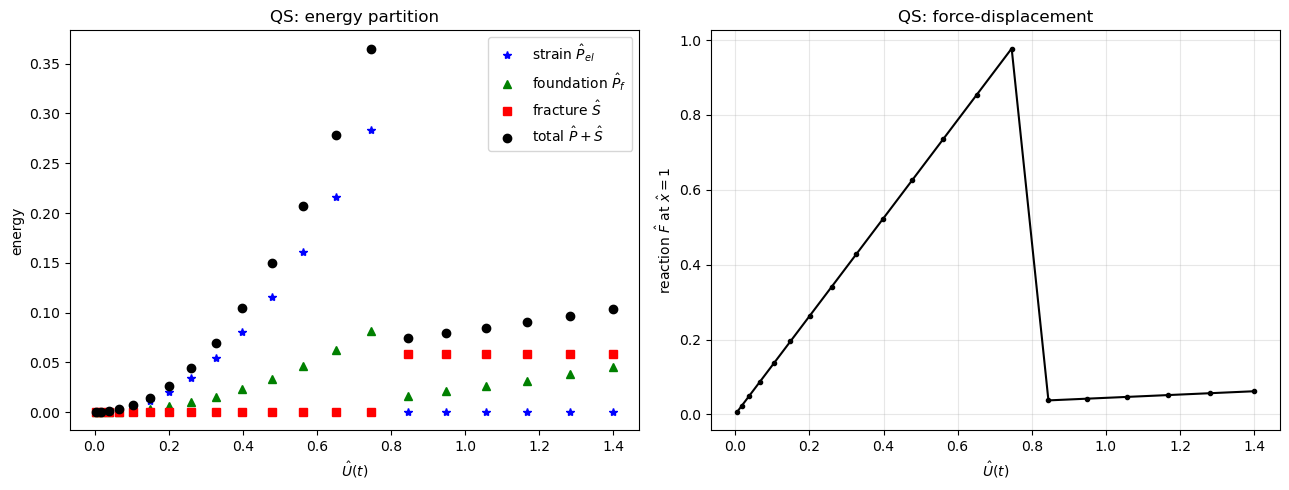

In [613]:
if comm.rank == 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(qs["U"], qs["P_el"],  "b*", label=r"strain $\hat{P}_{el}$")
    axes[0].plot(qs["U"], qs["P_f"],   "g^", label=r"foundation $\hat{P}_f$")
    axes[0].plot(qs["U"], qs["S"],     "rs", label=r"fracture $\hat{S}$")
    axes[0].plot(qs["U"], qs["total"], "ko", label=r"total $\hat{P}+\hat{S}$")
    axes[0].set_xlabel(r"$\hat{U}(t)$"); axes[0].set_ylabel("energy")
    axes[0].set_title("QS: energy partition")
    axes[0].legend()

    axes[1].plot(qs["U"], qs["F"], "k.-")
    axes[1].set_xlabel(r"$\hat{U}(t)$")
    axes[1].set_ylabel(r"reaction $\hat{F}$ at $\hat{x}=1$")
    axes[1].set_title("QS: force-displacement")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()


## Dynamic solver (Newmark-$\beta$ + alt-min)

In slow time:
$$
\eta^2 \ddot{\hat u} = \big((1-\alpha)^2 \hat u'\big)' - \Lambda^2 \hat u.
$$
Newmark-$\beta$ ($\beta = 1/4$, $\gamma = 1/2$ — average-acceleration, no numerical damping):
$$
\hat u_{n+1} = \hat u_n + \Delta t\,\dot{\hat u}_n + \tfrac{\Delta t^2}{2}\big((1-2\beta) a_n + 2\beta\, a_{n+1}\big)
$$
$$
\dot{\hat u}_{n+1} = \dot{\hat u}_n + \Delta t\big((1-\gamma) a_n + \gamma a_{n+1}\big)
$$

At each step alt-min between $a_{n+1}$ (linear) and $\alpha_{n+1}$ (VI). Once converged, propagate $u_{n+1}, v_{n+1}$ with the formulas above.

Time step is $\Delta t = 1 / N_\text{steps,dyn}$ — set once here from `loading_parameters["N_steps_dyn"]`.


In [614]:
beta_v  = Newmark_parameters["beta"]
gamma_v = Newmark_parameters["gamma"]

# Newmark expressions (in UFL form, used for symbolic substitution)
def u_newmark(u_, v_, a_, a_new_, dt):
    return u_ + dt*v_ + 0.5*dt**2 * ((1.0 - 2.0*beta_v)*a_ + 2.0*beta_v*a_new_)

def v_newmark(v_, a_, a_new_, dt):
    return v_ + dt*((1.0 - gamma_v)*a_ + gamma_v*a_new_)

# swap u -> u_newmark(...) in the acceleration residual.
# the inertia term already uses a_new directly, so nothing else to replace.
Res_acc_newmark = ufl.replace(Res_acc, {
    u: u_newmark(u, v, a, a_new, delta_t_c),
})

# alpha residual: depends on u, also swap u -> u_newmark
Res_alpha_dyn = ufl.replace(Res_alpha_qs, {
    u: u_newmark(u, v, a, a_new, delta_t_c),
})

J_acc_newmark = ufl.derivative(Res_acc_newmark, a_new, ufl.TrialFunction(V_u))
J_alpha_dyn   = ufl.derivative(Res_alpha_dyn,   alpha, ufl.TrialFunction(V_alpha))

acc_problem        = SNESProblem(Res_acc_newmark, a_new, bcs_a,     J=J_acc_newmark)
damage_problem_dyn = SNESProblem(Res_alpha_dyn,   alpha, bcs_alpha, J=J_alpha_dyn)

b_acc_dyn     = fem.petsc.create_vector(V_u)
J_acc_dyn_m   = fem.petsc.create_matrix(acc_problem.a)
b_alpha_dyn   = fem.petsc.create_vector(V_alpha)
J_alpha_dyn_m = fem.petsc.create_matrix(damage_problem_dyn.a)

# acceleration solver (linear)
solver_acc = PETSc.SNES().create()
solver_acc.setType("ksponly")
solver_acc.setFunction(acc_problem.F, b_acc_dyn)
solver_acc.setJacobian(acc_problem.J, J_acc_dyn_m)
solver_acc.setTolerances(rtol=1.0e-9, max_it=50)
solver_acc.getKSP().setType("preonly")
solver_acc.getKSP().getPC().setType("lu")
solver_acc.getKSP().getPC().setFactorSolverType("mumps")

# damage solver (VI, same flavor as in QS)
solver_alpha_dyn = PETSc.SNES().create()
solver_alpha_dyn.setType("vinewtonrsls")
solver_alpha_dyn.setFunction(damage_problem_dyn.F, b_alpha_dyn)
solver_alpha_dyn.setJacobian(damage_problem_dyn.J, J_alpha_dyn_m)
solver_alpha_dyn.setTolerances(rtol=1.0e-9, max_it=50)
solver_alpha_dyn.getKSP().setType("preonly")
solver_alpha_dyn.getKSP().getPC().setType("lu")
solver_alpha_dyn.setVariableBounds(alpha_lb.x.petsc_vec, alpha_ub.x.petsc_vec)
solver_alpha_dyn.getKSP().getPC().setFactorSolverType("mumps")

# make sure delta_t_c stays in sync with N_steps_dyn
delta_t_c.value = 1.0 / loading_parameters["N_steps_dyn"]


### Dynamic time loop

Start from rest ($u=v=a=0$, $\alpha=0$). Loop $N$ = `N_steps_dyn` times with $\Delta t = 1/N$. The $t = 0$ state is not recorded, so the recorded arrays have length exactly $N$ (same convention as QS).


In [615]:
# zero everything
u.x.array[:]     = 0.0; u_new.x.array[:] = 0.0
v.x.array[:]     = 0.0; v_new.x.array[:] = 0.0
a.x.array[:]     = 0.0; a_new.x.array[:] = 0.0
alpha.x.array[:]    = 0.0
alpha_lb.x.array[:] = 0.0
alpha_ub.x.array[:] = 1.0

dyn = {"t": [], "U": [], "F": [],
       "K": [], "P_el": [], "P_f": [], "S": [], "total": []}

N_dyn = loading_parameters["N_steps_dyn"]
dt    = 1.0 / N_dyn

t_cur = 0.0
for step in range(N_dyn):
    t_cur += dt
    # BCs at the NEW time (Newmark wants u_{n+1} = U(t_{n+1}) at the right end)
    u_right_val.value = float(U_fn(t_cur))
    v_right_val.value = float(V_fn(t_cur))
    a_right_val.value = float(A_fn(t_cur))

    # alt-min between a_new and alpha
    n_alt = 0
    for n_alt in range(1, AltMin_parameters["max_iter"] + 1):
        solver_acc.solve(None, a_new.x.petsc_vec)
        a_new.x.petsc_vec.ghostUpdate(
            addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD
        )
        solver_alpha_dyn.solve(None, alpha.x.petsc_vec)
        alpha.x.petsc_vec.ghostUpdate(
            addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD
        )

        err = comm.allreduce(fem.assemble_scalar(error_L2_alpha_form), op=MPI.SUM)
        err_alpha = float(np.sqrt(max(err, 0.0)))
        alpha_old_iter.x.array[:] = alpha.x.array

        if err_alpha <= AltMin_parameters["tol"]:
            break

    # explicit Newmark update of u_new, v_new
    u_new.x.array[:] = (u.x.array
                        + dt * v.x.array
                        + 0.5 * dt**2 * ((1.0 - 2.0*beta_v) * a.x.array
                                          + 2.0*beta_v * a_new.x.array))
    v_new.x.array[:] = (v.x.array
                        + dt * ((1.0 - gamma_v) * a.x.array
                                + gamma_v * a_new.x.array))
    # boundaries must hit the imposed values exactly
    fem.set_bc(u_new.x.petsc_vec, bcs_u)
    fem.set_bc(v_new.x.petsc_vec, bcs_v)
    u_new.x.petsc_vec.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)
    v_new.x.petsc_vec.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)

    # n+1 becomes n
    u.x.array[:] = u_new.x.array
    v.x.array[:] = v_new.x.array
    a.x.array[:] = a_new.x.array
    alpha_lb.x.array[:] = alpha.x.array   # irreversibility

    # record
    dyn["t"].append(t_cur)
    dyn["U"].append(float(u_right_val.value))
    dyn["F"].append(comm.allreduce(fem.assemble_scalar(reaction_right_form), op=MPI.SUM))
    dyn["K"].append(comm.allreduce(fem.assemble_scalar(kinetic_energy_form), op=MPI.SUM))
    dyn["P_el"].append(comm.allreduce(fem.assemble_scalar(strain_energy_form),     op=MPI.SUM))
    dyn["P_f"].append(comm.allreduce(fem.assemble_scalar(foundation_energy_form), op=MPI.SUM))
    dyn["S"].append(comm.allreduce(fem.assemble_scalar(fracture_energy_form),     op=MPI.SUM))
    dyn["total"].append(dyn["K"][-1] + dyn["P_el"][-1] + dyn["P_f"][-1] + dyn["S"][-1])

    # print every 10 steps (and the last one)
    if comm.rank == 0 and ((step + 1) % 10 == 0 or step == N_dyn - 1):
        denom = max(1.0e-12, dyn["total"][-1])
        print(f"Dyn step {step+1:4d}/{N_dyn}: "
              f"t={t_cur:.4f}  U={dyn['U'][-1]:.4f}  F={dyn['F'][-1]:.4f}  "
              f"K/total={dyn['K'][-1]/denom:.2e}  alt_min_it={n_alt}")

u_dyn_final     = u.x.array.copy()
alpha_dyn_final = alpha.x.array.copy()
for k in dyn: dyn[k] = np.array(dyn[k])


Dyn step   10/60: t=0.1667  U=0.0466  F=0.0619  K/total=3.49e-03  alt_min_it=1
Dyn step   20/60: t=0.3333  U=0.1828  F=0.2406  K/total=8.13e-04  alt_min_it=1
Dyn step   30/60: t=0.5000  U=0.3989  F=0.5237  K/total=3.26e-04  alt_min_it=1
Dyn step   40/60: t=0.6667  U=0.6822  F=0.8952  K/total=1.66e-04  alt_min_it=1
Dyn step   50/60: t=0.8333  U=1.0197  F=0.0254  K/total=1.33e-01  alt_min_it=3
Dyn step   60/60: t=1.0000  U=1.4000  F=0.0279  K/total=2.52e-01  alt_min_it=2


### Dynamic plots

Energies vs slow time and reaction force vs slow time, in the style of the elastodynamics notebook.


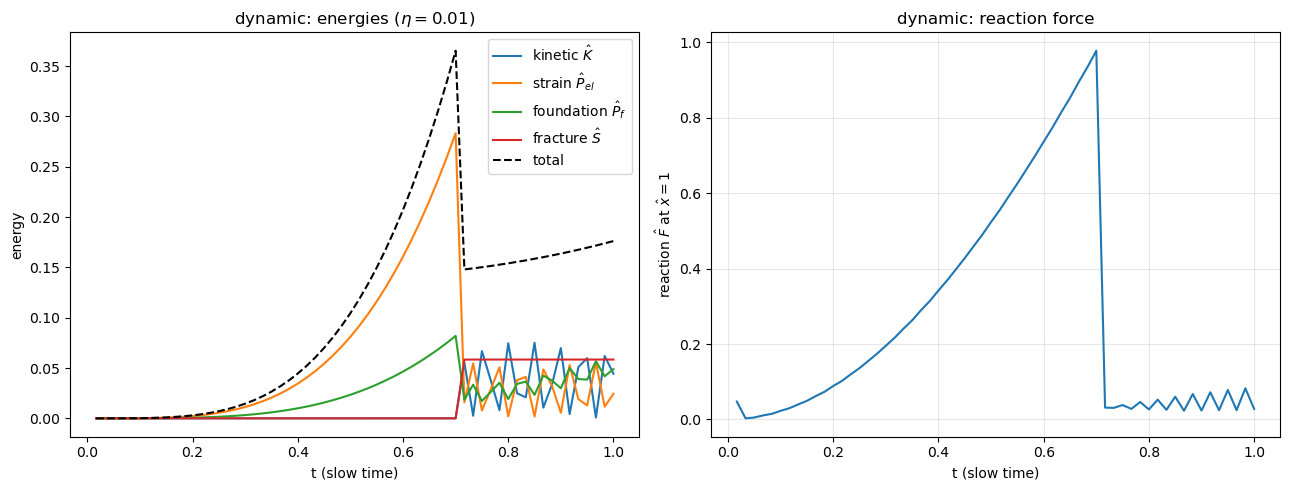

In [616]:
if comm.rank == 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(dyn["t"], dyn["K"],     label=r"kinetic $\hat{K}$")
    axes[0].plot(dyn["t"], dyn["P_el"],  label=r"strain $\hat{P}_{el}$")
    axes[0].plot(dyn["t"], dyn["P_f"],   label=r"foundation $\hat{P}_f$")
    axes[0].plot(dyn["t"], dyn["S"],     label=r"fracture $\hat{S}$")
    axes[0].plot(dyn["t"], dyn["total"], "k--", label="total")
    axes[0].set_xlabel("t (slow time)"); axes[0].set_ylabel("energy")
    axes[0].set_title(r"dynamic: energies ($\eta=%g$)" % model_parameters["eta"])
    axes[0].legend()

    axes[1].plot(dyn["t"], dyn["F"])
    axes[1].set_xlabel("t (slow time)")
    axes[1].set_ylabel(r"reaction $\hat{F}$ at $\hat{x}=1$")
    axes[1].set_title("dynamic: reaction force")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()


## Comparison QS vs Dynamic

Both solvers ran on the same loading $\hat U(t)$, so plotting against $\hat U$ is a fair comparison.

Layout:
- top-left: force vs $\hat U$,
- top-right: final damage profile $\alpha(\hat x)$,
- bottom (wide): all energies vs $\hat U$, including the kinetic $\hat K$ (only the dynamic solver has it).

A note on the "total" gap visible after the snap-back:
- $\text{Total}_\text{QS} = \hat P_{el} + \hat P_f + \hat S$
- $\text{Total}_\text{dyn} = \hat K + \hat P_{el} + \hat P_f + \hat S$

So the gap comes from (i) $\hat K$ directly, and (ii) a small post-crack overshoot in $\hat P_{el}$ and $\hat P_f$ because there is no viscous damping — the energy released by the snap bounces between $\hat K$, $\hat P_{el}$ and $\hat P_f$ instead of being thrown away (as it effectively is in the QS minimization).

The figure is also saved to `Output/` as `.png` and `.pdf`, with a filename built from the run parameters.


/tmp/ipykernel_1091079/3558526238.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.93])


Results saved to Output/
  - lhat_0.02_lam_1.0_eta_0.01_umax_1.40_nQS_20_nDyn_60.png
  - lhat_0.02_lam_1.0_eta_0.01_umax_1.40_nQS_20_nDyn_60.pdf


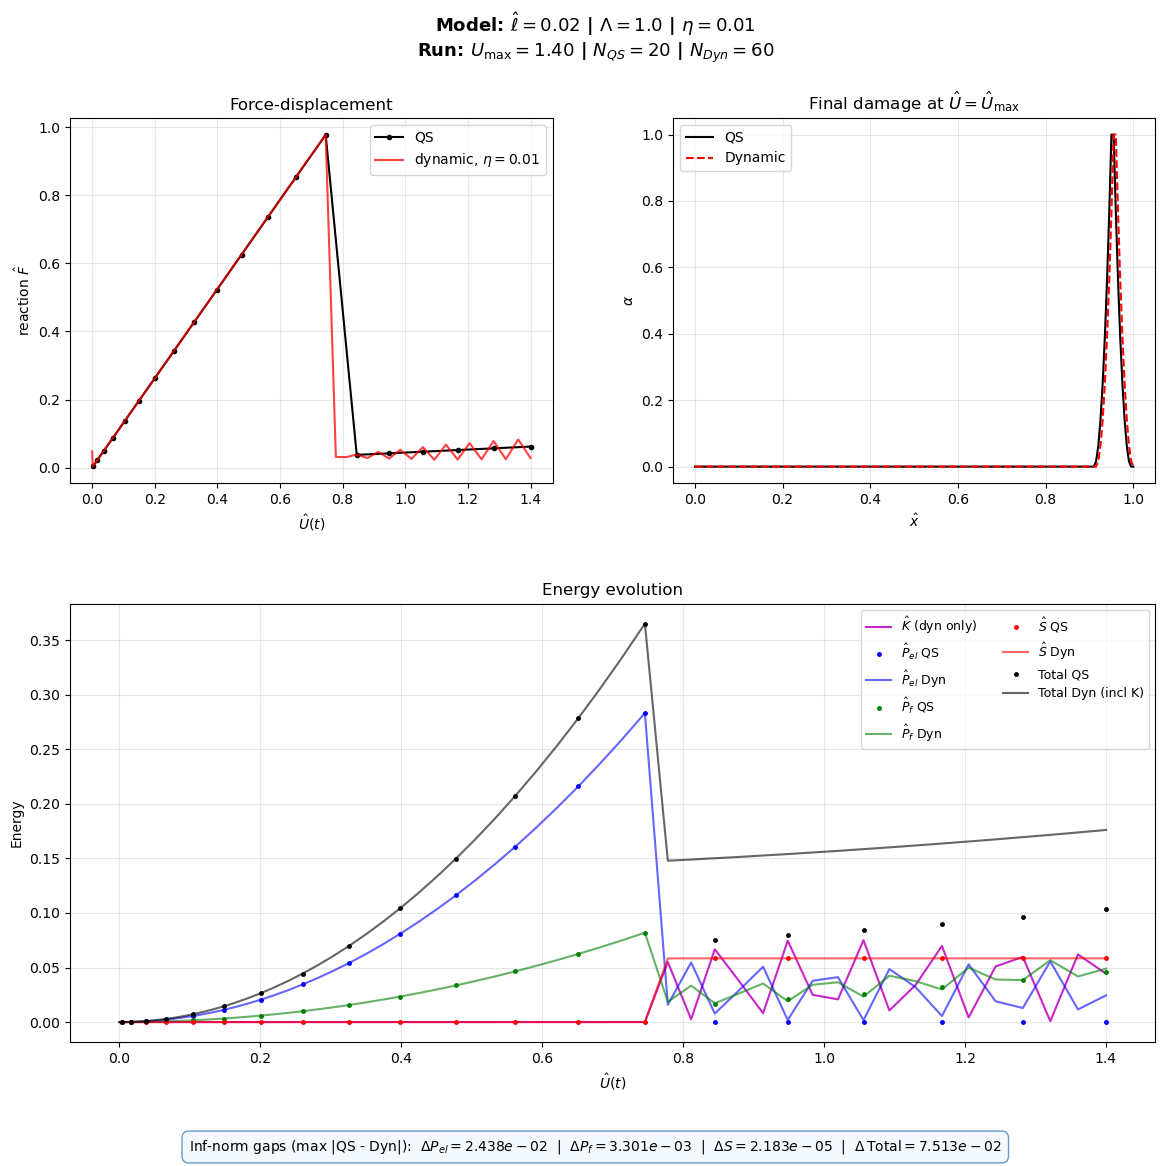

In [617]:
# --- 1. data prep and error metrics ---

# node x-coordinates for plotting the final damage profile
x_alpha  = V_alpha.tabulate_dof_coordinates()[:, 0]
ix_alpha = np.argsort(x_alpha)

# interpolate dyn energies onto the QS U-grid for the inf-norm errors
P_el_dyn_at_qs = np.interp(qs["U"], dyn["U"], dyn["P_el"])
P_f_dyn_at_qs  = np.interp(qs["U"], dyn["U"], dyn["P_f"])
S_dyn_at_qs    = np.interp(qs["U"], dyn["U"], dyn["S"])
tot_dyn_at_qs  = np.interp(qs["U"], dyn["U"], dyn["total"])

err_P_el = float(np.max(np.abs(qs["P_el"]  - P_el_dyn_at_qs)))
err_P_f  = float(np.max(np.abs(qs["P_f"]   - P_f_dyn_at_qs)))
err_S    = float(np.max(np.abs(qs["S"]     - S_dyn_at_qs)))
err_tot  = float(np.max(np.abs(qs["total"] - tot_dyn_at_qs)))

# --- 2. plotting and saving ---

if comm.rank == 0:
    # gridspec: row 0 has two panels, row 1 has one wide panel for the energies
    fig = plt.figure(figsize=(14, 12))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.2], hspace=0.30, wspace=0.25)
    ax_force  = fig.add_subplot(gs[0, 0])
    ax_dam    = fig.add_subplot(gs[0, 1])
    ax_energy = fig.add_subplot(gs[1, :])

    # metadata used in title + filename
    u_max_val   = float(np.max(qs["U"]))
    n_steps_qs  = len(qs["U"])
    n_steps_dyn = len(dyn["U"])
    eta_val     = model_parameters["eta"]
    ell_val     = model_parameters["l_hat"]
    lambda_val  = model_parameters["Lambda"]

    header_text = (
        f"Model: $\\hat\\ell = {ell_val}$ | $\\Lambda = {lambda_val}$ | $\\eta = {eta_val}$\n"
        f"Run: $U_{{\\max}} = {u_max_val:.2f}$ | $N_{{QS}} = {n_steps_qs}$ | $N_{{Dyn}} = {n_steps_dyn}$"
    )
    fig.suptitle(header_text, fontsize=13, fontweight="bold", y=0.97)

    # (top-left) force-displacement
    ax_force.plot(qs["U"],  qs["F"],  "k.-", label="QS")
    ax_force.plot(dyn["U"], dyn["F"], "r-",
                  label=r"dynamic, $\eta=%g$" % eta_val, alpha=0.75)
    ax_force.set_xlabel(r"$\hat{U}(t)$")
    ax_force.set_ylabel(r"reaction $\hat{F}$")
    ax_force.set_title("Force-displacement")
    ax_force.grid(True, alpha=0.3); ax_force.legend()

    # (top-right) final damage profile
    ax_dam.plot(x_alpha[ix_alpha], alpha_qs_final[ix_alpha],  "k-",  label="QS")
    ax_dam.plot(x_alpha[ix_alpha], alpha_dyn_final[ix_alpha], "r--", label="Dynamic")
    ax_dam.set_xlabel(r"$\hat{x}$"); ax_dam.set_ylabel(r"$\alpha$")
    ax_dam.set_title(r"Final damage at $\hat{U}=\hat{U}_{\rm max}$")
    ax_dam.grid(True, alpha=0.3); ax_dam.legend()

    # (bottom, wide) energy overview
    ax_energy.plot(dyn["U"], dyn["K"],     "m-",  alpha=0.85,  label=r"$\hat{K}$ (dyn only)")
    ax_energy.plot(qs["U"],  qs["P_el"],   "b.",  markersize=5, label=r"$\hat{P}_{el}$ QS")
    ax_energy.plot(dyn["U"], dyn["P_el"],  "b-",  alpha=0.6,    label=r"$\hat{P}_{el}$ Dyn")
    ax_energy.plot(qs["U"],  qs["P_f"],    "g.",  markersize=5, label=r"$\hat{P}_f$ QS")
    ax_energy.plot(dyn["U"], dyn["P_f"],   "g-",  alpha=0.6,    label=r"$\hat{P}_f$ Dyn")
    ax_energy.plot(qs["U"],  qs["S"],      "r.",  markersize=5, label=r"$\hat{S}$ QS")
    ax_energy.plot(dyn["U"], dyn["S"],     "r-",  alpha=0.6,    label=r"$\hat{S}$ Dyn")
    ax_energy.plot(qs["U"],  qs["total"],  "k.",  markersize=5, label="Total QS")
    ax_energy.plot(dyn["U"], dyn["total"], "k-",  alpha=0.6,    label="Total Dyn (incl K)")
    ax_energy.set_xlabel(r"$\hat{U}(t)$"); ax_energy.set_ylabel("Energy")
    ax_energy.set_title("Energy evolution")
    ax_energy.grid(True, alpha=0.3)
    ax_energy.legend(fontsize=9, ncol=2, loc="best")

    # footer with the inf-norm gaps
    err_text = (
        f"Inf-norm gaps (max |QS - Dyn|):  "
        f"$\\Delta P_{{el}} = {err_P_el:.3e}$  |  "
        f"$\\Delta P_f = {err_P_f:.3e}$  |  "
        f"$\\Delta S = {err_S:.3e}$  |  "
        f"$\\Delta\\,\\mathrm{{Total}} = {err_tot:.3e}$"
    )
    fig.text(0.5, 0.015, err_text, ha="center", va="bottom", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.5", facecolor="aliceblue",
                       edgecolor="steelblue", alpha=0.8))

    plt.tight_layout(rect=[0, 0.05, 1, 0.93])

    # --- save ---
    output_dir = "Output"
    os.makedirs(output_dir, exist_ok=True)

    filename_str = (
        f"lhat_{ell_val}_lam_{lambda_val}_eta_{eta_val}_"
        f"umax_{u_max_val:.2f}_nQS_{n_steps_qs}_nDyn_{n_steps_dyn}"
    )
    png_path = os.path.join(output_dir, f"{filename_str}.png")
    pdf_path = os.path.join(output_dir, f"{filename_str}.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path,            bbox_inches="tight")

    print(f"Results saved to {output_dir}/")
    print(f"  - {filename_str}.png")
    print(f"  - {filename_str}.pdf")

    plt.show()


## Notes

- Push $\eta$ down (e.g. $10^{-3}$) and the curves overlap even better.
- Push $\eta$ up toward $\mathcal O(1)$ and inertia kicks in: wave reflections show up in the force trace and the dynamic energies separate from QS.
- To explore the wave regime, also raise `N_steps_dyn` so the fastest wave period ($\sim \eta$) is resolved.
- The energy forms ($\hat P, \hat S, \hat K$) are defined once and shared between solvers; only the residuals differ by the $\eta^2 \ddot{\hat u}$ term.
